# Exercise 1

# Multiple Linear Regression

In [2]:
import pandas as pd

# Load and verify the dataset
df = pd.read_csv(r"C:\Users\HP\A  Self Pace ML\20. Multiple Linear Regression\homeprices.csv")
print(df)

   area  bedrooms  age   price
0  2600       3.0   20  550000
1  3000       4.0   15  565000
2  3200       NaN   18  610000
3  3600       3.0   30  595000
4  4000       5.0    8  760000


In [7]:
df.columns

Index(['area', 'bedrooms', 'age', 'price'], dtype='object')

In [3]:
df.isnull().sum()

area        0
bedrooms    1
age         0
price       0
dtype: int64

In [4]:
df.bedrooms.median()

3.5

In [10]:
import math 
med = math.floor(df.bedrooms.median())
med

3

In [11]:
# Fill missing values in the bedrooms column with the median calculated
df['bedrooms'] = df['bedrooms'].fillna(med)

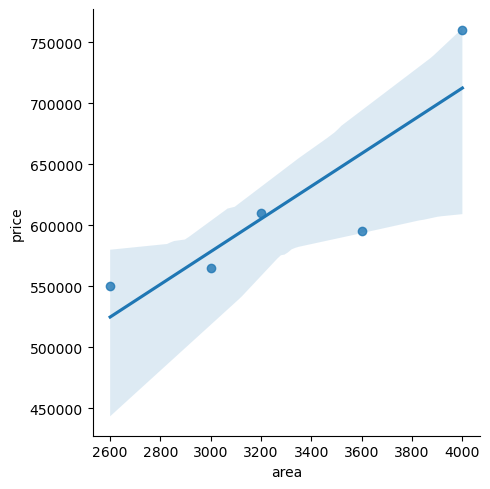

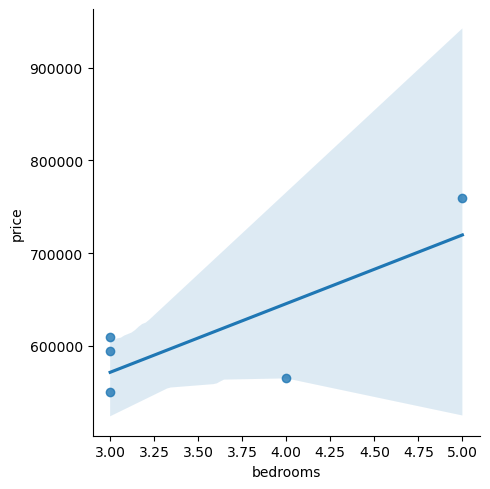

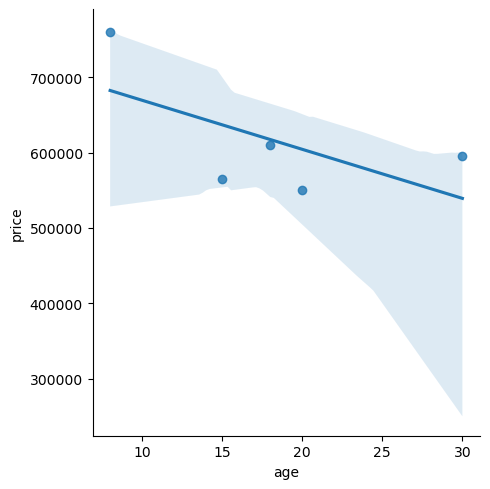

In [12]:
# represent the relations between independent and dependent vars 
# area, bedrooms and age are independent vars and price is dependent 

import seaborn as sns
sns.lmplot(x = 'area', y='price', data=df)
sns.lmplot(x = 'bedrooms', y='price', data=df)
sns.lmplot(x = 'age' , y='price', data=df)

In [13]:
# create linear regression model with multiple variables 
# take the independent bars first and take dependent var next. 

from sklearn.linear_model import LinearRegression
reg = LinearRegression() 
reg.fit(df[['area', 'bedrooms', 'age']], df['price']) 

# fitting means traning

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [14]:
# print coefficients 
reg.coef_

array([   137.25, -26025.  ,  -6825.  ])

In [15]:
# intercept 
reg.intercept_

np.float64(383724.9999999999)

In [16]:
# predict the price of 3000 sqft area, 3 bedrooms, 40 years old house 
reg.predict([[3000,3,40]])

C:\Users\HP\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([444400.])

In [17]:
reg.predict([[2500,4,5]])

C:\Users\HP\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([588625.])

#### accuracy

In [18]:
# Pass your independent variables and the actual true targets
accuracy = reg.score(df[['area', 'bedrooms', 'age']], df['price'])
print(f"R^2 Accuracy Score: {accuracy * 100:.2f}%") 

R^2 Accuracy Score: 94.89%


# Exercise 2

## ca11-03homes.xls

In [8]:
import pandas as pd

# Load and verify the dataset
df = pd.read_excel('ca11-03homes.xlsx')
df.head()

,Observation,Price,Square Foot Area,Bed Rooms,Bath Rooms,Garage,Location,Year Built,Zip Code
0,1,1182272,4462,2,1,0,Sacramento,2006,94018
1,2,1535744,4164,3,5,3,San Diego,1990,91984
2,3,883624,3354,1,1,3,Los Angeles,2000,90863
3,4,525200,1528,5,3,3,Los Angeles,1971,93596
4,5,435280,1260,3,4,2,Sacramento,2023,95880


In [9]:
df.shape

(504, 9)

In [11]:
df.columns


Index(['Observation', 'Price', 'Square Foot Area', 'Bed Rooms', 'Bath Rooms',
       'Garage', 'Location', 'Year Built', 'Zip Code'],
      dtype='object')

In [10]:
import matplotlib.pyplot as plt 
import seaborn as sns


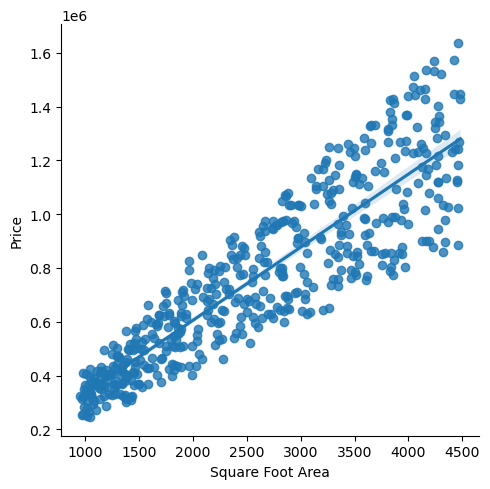

In [13]:
sns.lmplot(x = 'Square Foot Area', y = 'Price', data = df)

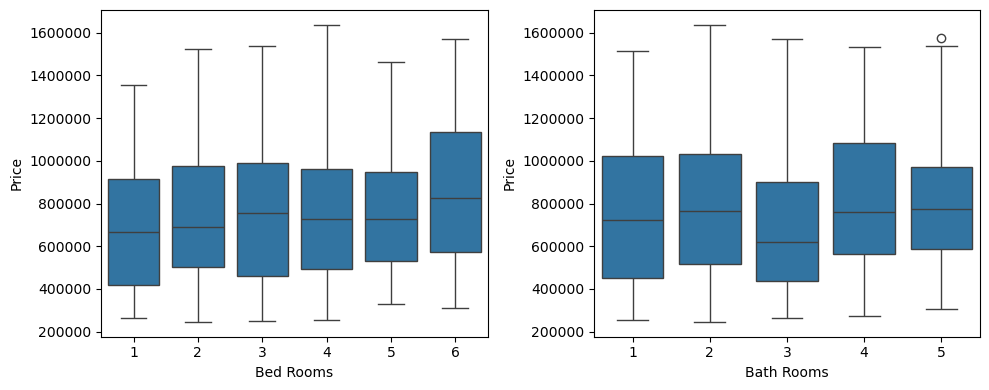

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 4))

# Left Plot: Bed Rooms vs Price
plt.subplot(1, 2, 1)
sns.boxplot(x='Bed Rooms', y='Price', data=df)
plt.ticklabel_format(style='plain', axis='y')  # Forces integer formatting on Y-axis

# Right Plot: Bath Rooms vs Price
plt.subplot(1, 2, 2)
sns.boxplot(x='Bath Rooms', y='Price', data=df)
plt.ticklabel_format(style='plain', axis='y')  # Forces integer formatting on Y-axis

plt.tight_layout() # Keeps the plots neatly spaced
plt.show()

#### finding abnormal values in Price

In [41]:
# calculate  iqr 
q3 = df['Price'].quantile(.75) 
q1 = df['Price'].quantile(.25) 
iqr = q3 - q1

In [44]:
# calculate upper and lower limits from iqr 
ul = q3 + (1.5*iqr) 
ll = q1 - (1.5*iqr)

In [45]:
# Price should not be more than ul and less than ll 
# if it is so , then it becomes outliers 

import numpy as np
upper = np.where(df['Price']>=ul) 
lower = np.where(df['Price']<=ll)

In [48]:
upper
lower

(array([], dtype=int64),)

In [50]:
df.drop(upper[0], inplace=True) 
df.drop(lower[0], inplace = True)

In [51]:
df.head()

,Observation,Price,Square Foot Area,Bed Rooms,Bath Rooms,Garage,Location,Year Built,Zip Code
0,1,1182272,4462,2,1,0,Sacramento,2006,94018
1,2,1535744,4164,3,5,3,San Diego,1990,91984
2,3,883624,3354,1,1,3,Los Angeles,2000,90863
3,4,525200,1528,5,3,3,Los Angeles,1971,93596
4,5,435280,1260,3,4,2,Sacramento,2023,95880


In [55]:
# retrive only 2nd,3rd and 4th columns and take them as xabs
x = df.iloc[:,2:5].values

#retrive 1st column and take it as y 
y = df.iloc[:,1].values

#### Supply data to the ML Model

In [56]:
from sklearn.model_selection import train_test_split
x_train, x_test , y_train , y_test = train_test_split(x , y, test_size=.2, random_state=10)

#### train the computer with simple LinearRegression Model

In [57]:
from sklearn.linear_model import LinearRegression
reg = LinearRegression() 

#### train the model

In [58]:
reg.fit(x_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [69]:
# test the model by pasiing test data and obtain predicted data 
y_pred = reg.predict(x_test)
y_pred

array([1213259.50231658,  460057.39155692,  523761.0624583 ,
        364018.13715329,  350615.71013425,  764768.16140059,
        887436.71465097,  718037.96736199, 1266209.08684762,
        395079.90107784,  945986.50296845, 1030410.25576769,
        999474.1074699 ,  994580.23214574, 1215411.58219816,
        354310.61957873, 1188238.88400527,  878073.06075962,
        674941.98445181,  882428.91611338, 1222357.76957244,
        418283.30046531, 1072052.41819494, 1299958.26093628,
        424328.06942827,  525327.05012861,  383049.30544193,
       1098512.47488796,  419482.26634499,  568637.65774552,
        819062.79585762,  703388.5022224 ,  337558.08046027,
       1048651.23917057,  534278.29967632,  386150.87597571,
       1006027.42525824,  535500.42366343, 1174691.30660177,
        536087.44953654,  915686.38644649,  900495.27798679,
       1179782.02790098,  646624.7056577 ,  972349.48151788,
        904610.66083852,  628818.35104403,  973642.83585328,
        920427.86468675,

#### find the r squared balue by comparing test data 

In [62]:
from sklearn.metrics import r2_score
r2_score(y_test, y_pred)

0.777289960430405

In [63]:
reg.score(x_test, y_test)

0.777289960430405

#### Question 1

In [67]:
# Predict the price of a house with 780 sqft , 3 bedrooms and 1 bathrooms 

print(reg.predict([[780,3,1]]))

[266244.58658745]


#### Question 2

In [68]:
# Predict the prices of houses with 1522sqft , 3 bedrooms , and 2 bathrooms 
print(reg.predict([[1522,3,2]]))

[469470.05135098]


# --End--